In [124]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import sklearn
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
from sklearn.model_selection import train_test_split

In [120]:
# Load dataset
df = pd.read_csv("data/merged_dengue_dataset.csv")

In [121]:
## Preprocessing
# Drop rows with missing TAT
df_clean = df.dropna(subset=["pre_median_turnaround_days"]).copy()

# Drop redundant columns
cols_to_drop = [
    'post_cases', 'post_genome_count', 'post_genomes_per_1000',
    'post_median_turnaround_days', 'overall_median_turnaround_days',
    'pre_genomes_per_1000', 'pre_cases', 'pre_genome_count',
    'treatment_Publicfrac_pred_high', 'treatment_Publicfrac_pred_low',
    'risk_DCZ_pop_risk_upper', 'risk_DCZ_pop_risk_lower',
    'risk_YF_pop_risk_upper', 'risk_YF_pop_risk_lower',
    'income',  # drop income since it's a duplicate of group
    'gdp_gdp_usd_mean'  # keep only PPP GDP
]
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)

# Helper to configure OneHotEncoder
def make_ohe(drop_arg):
    params = {"drop": drop_arg}
    # ensure dense output
    if sklearn.__version__ >= "1.2":
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)

# One-hot encode 'group' (dropping the first level)
ohe_group = make_ohe(drop_arg="first")
group_ohe = ohe_group.fit_transform(df_clean[["group"]])
group_cols = ohe_group.get_feature_names_out(["group"])
group_df = pd.DataFrame(group_ohe, columns=group_cols, index=df_clean.index)

# One-hot encode 'Risk' (dropping 'none' as the baseline)
ohe_risk = make_ohe(drop_arg=["none"])
risk_ohe = ohe_risk.fit_transform(df_clean[["Risk"]])
risk_cols = ohe_risk.get_feature_names_out(["Risk"])
risk_df = pd.DataFrame(risk_ohe, columns=risk_cols, index=df_clean.index)

# Combine everything back into one DataFrame
df_encoded = pd.concat(
    [ df_clean.drop(columns=["group", "Risk"]), group_df, risk_df ],
    axis=1
)

# Inspect
print(df_encoded.head())

  country_code  pre_median_turnaround_days income_country_name  \
0          AGO                      1002.5              Angola   
2          ARG                       562.0           Argentina   
3          AUS                      2776.0           Australia   
4          BEN                      1485.5               Benin   
5          BFA                       893.0        Burkina Faso   

  risk_country_name  risk_Surveillance_score  risk_Total_population  \
0            Angola                    0.578                 33.375   
2         Argentina                    0.842                 45.744   
3         Australia                    0.865                 24.222   
4             Benin                    0.596                 13.617   
5      Burkina Faso                    0.322                 21.990   

   risk_DCZ_pop_risk_mean  risk_YF_pop_risk_mean  rd_value    gov_cc  ...  \
0                  28.289                 25.748  0.032290 -1.158571  ...   
2                  39.

In [122]:
# Log-transform TAT
df_encoded['log_TAT'] = np.log(df_encoded['pre_median_turnaround_days'])

In [130]:
# Regression time!

# Define features
exclude_cols = [
    'country_code', 'income_country_name', 'risk_country_name',
    'pre_median_turnaround_days', 'log_TAT',
    'TAT_residual'
]
feature_cols = [
    c for c in df_encoded.columns
    if c not in exclude_cols
       and df_encoded[c].dtype in (np.number, np.int64, np.float64)
]

X = df_encoded[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_encoded['log_TAT']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% hold-out
    random_state=42
)

# Build & fit pipeline on TRAIN
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)
model.fit(X_train, y_train)

# Evaluate on TEST
y_pred_test = model.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"Test R²:  {r2_test:.3f}")
print(f"Test MSE: {mse_test:.3f}")

# Inspect coefficients
ridge = model.named_steps['ridge']
coef_df = (
    pd.DataFrame({
        'feature': feature_cols,
        'coef': ridge.coef_
    })
    .assign(abs_coef=lambda df: df.coef.abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
)
print("\nTop 10 coefs by magnitude:")
print(coef_df.head(10).to_string(index=False))

y_pred_full = model.predict(X)
residuals_full = y - y_pred_full

Test R²:  -0.711
Test MSE: 0.701

Top 10 coefs by magnitude:
      feature      coef
Risk_sporadic -0.384681
       gov_va  0.214423
Risk_frequent -0.193175
       gov_pv  0.186845
    group_LIC  0.153511
       gov_cc -0.117398
       gov_rl -0.116171
     rd_value  0.112397
       gov_ge  0.103600
    group_UMC -0.087822


/var/folders/nw/jnrc_9qd2kv15xjq83h1yqh80000gn/T/ipykernel_41742/889665309.py:12: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  and df_encoded[c].dtype in (np.number, np.int64, np.float64)


In [126]:
# OLS regression
# Add constant for intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Fit OLS on the training data
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Inspect the full summary
print(ols_model.summary())

# Evaluate on the test set
y_pred_test = ols_model.predict(X_test_sm)
r2_test = sm.tools.eval_measures.rsquared(y_test, y_pred_test)
mse_test = np.mean((y_test - y_pred_test)**2)

print(f"\nTest   R²:  {r2_test:.3f}")
print(f"Test  MSE:  {mse_test:.3f}")

                            OLS Regression Results                            
Dep. Variable:                log_TAT   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     1.790
Date:                Wed, 06 Aug 2025   Prob (F-statistic):             0.0538
Time:                        10:58:48   Log-Likelihood:                -30.702
No. Observations:                  65   AIC:                             103.4
Df Residuals:                      44   BIC:                             149.1
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

AttributeError: module 'statsmodels.tools.eval_measures' has no attribute 'rsquared'

Intercept: 7.253091744384158

Top 10 coefficients (by magnitude):
      Feature  Coefficient
Risk_sporadic    -0.384681
       gov_va     0.214423
Risk_frequent    -0.193175
       gov_pv     0.186845
    group_LIC     0.153511
       gov_cc    -0.117398
       gov_rl    -0.116171
     rd_value     0.112397
       gov_ge     0.103600
    group_UMC    -0.087822

R^2 score: 0.998
MSE:      0.001


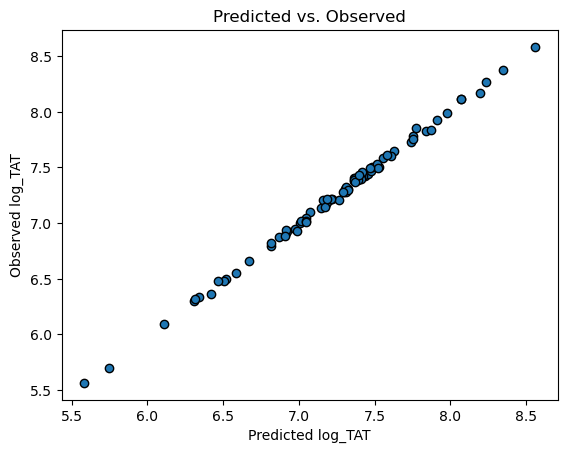

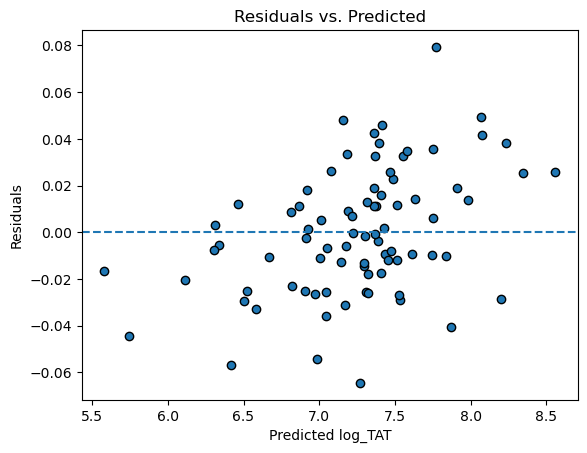

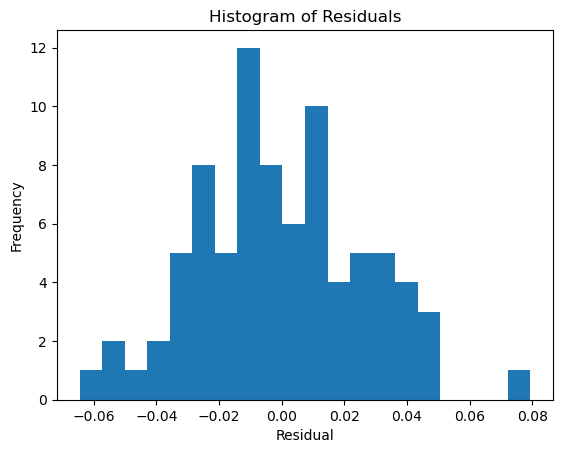

In [127]:
# Now print & plot
print("Intercept:", ridge.intercept_)

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nTop 10 coefficients (by magnitude):")
print(coef_df.head(10).to_string(index=False))

print(f"\nR^2 score: {r2_score(y, y_pred):.3f}")
print(f"MSE:      {mean_squared_error(y, y_pred):.3f}")

# a) Predicted vs Observed
plt.figure()
plt.scatter(y_pred, y, edgecolor='k')
plt.xlabel("Predicted log_TAT")
plt.ylabel("Observed log_TAT")
plt.title("Predicted vs. Observed")
plt.show()

# b) Residuals vs Predicted
plt.figure()
plt.scatter(y_pred, residuals, edgecolor='k')
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted log_TAT")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()

# c) Histogram of Residuals
plt.figure()
plt.hist(residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

In [64]:
# Cluster residuals
kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded['TAT_cluster'] = kmeans.fit_predict(df_encoded[['TAT_residual']])

In [65]:
# Print summary
cluster_summary = df_encoded.groupby('TAT_cluster')['pre_median_turnaround_days'].describe()
print(cluster_summary)

# Save clustered data
df_encoded.to_csv("results/clusters/clustered_dengue_TAT.csv", index=False)

             count         mean          std     min      25%      50%  \
TAT_cluster                                                              
0             46.0  1580.945652   605.556486   578.0  1272.75  1503.25   
1             19.0   852.605263   407.860256   261.0   558.00   779.50   
2             17.0  2571.411765  1061.220262  1250.5  1705.50  2409.00   

                 75%     max  
TAT_cluster                   
0            1785.75  4325.0  
1            1073.25  1695.0  
2            3345.00  5351.5  


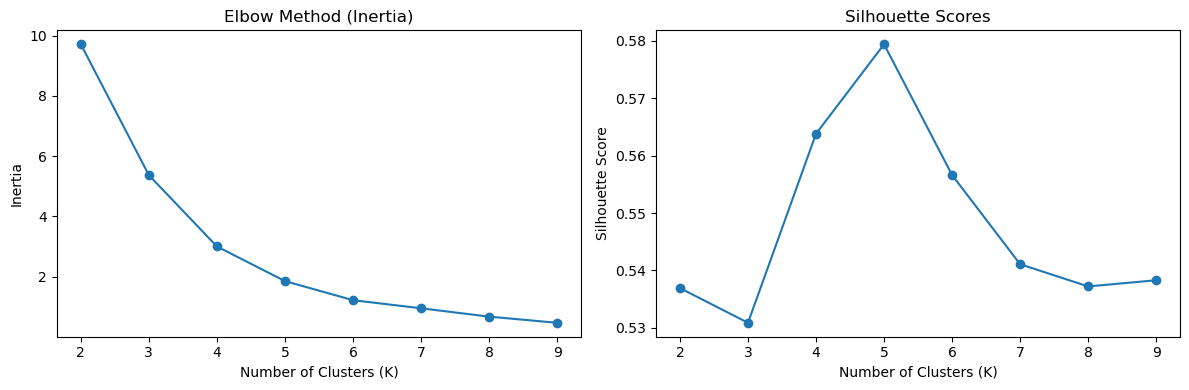

In [131]:
# Elbow and Silhouette Methods
#    Reshape into a 2D array for sklearn
resid_vals = residuals_full.values.reshape(-1, 1)

inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(resid_vals)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(resid_vals, labels))

# Plot your diagnostics
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [134]:
# Time to cluster
y_pred_full = model.predict(X)  
residuals_full = (y - y_pred_full).values.reshape(-1, 1)

# Cluster residuals into 5 groups as according to plots
cluster_model = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=5, random_state=42)
)

df_encoded['TAT_cluster'] = cluster_model.fit_predict(residuals_full)

# Summarise by cluster
summary = df_encoded.groupby('TAT_cluster')['pre_median_turnaround_days'].describe()
print(summary)

# Save out
df_encoded.to_csv("results/clusters/clustered_dengue_TAT.csv", index=False)

             count         mean          std     min       25%      50%  \
TAT_cluster                                                               
0              9.0  3193.444444  1224.196508  1679.0  2090.500  3345.00   
1             22.0  1161.636364   303.403518   554.0   986.125  1113.25   
2             42.0  1735.023810   562.087344   578.0  1452.625  1660.50   
3              2.0   370.500000   101.116270   299.0   334.750   370.50   
4              7.0   675.428571   273.385477   261.0   552.500   649.00   

                  75%     max  
TAT_cluster                    
0            3912.000  5351.5  
1            1365.375  1695.0  
2            1848.125  3356.0  
3             406.250   442.0  
4             796.500  1120.0  


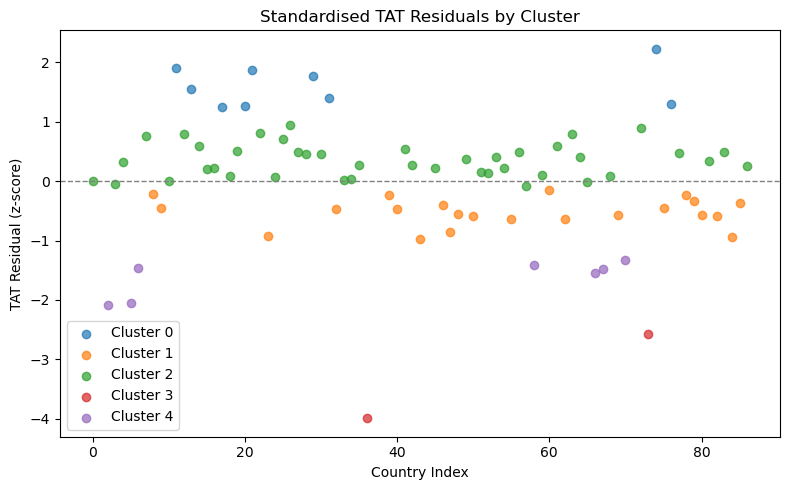

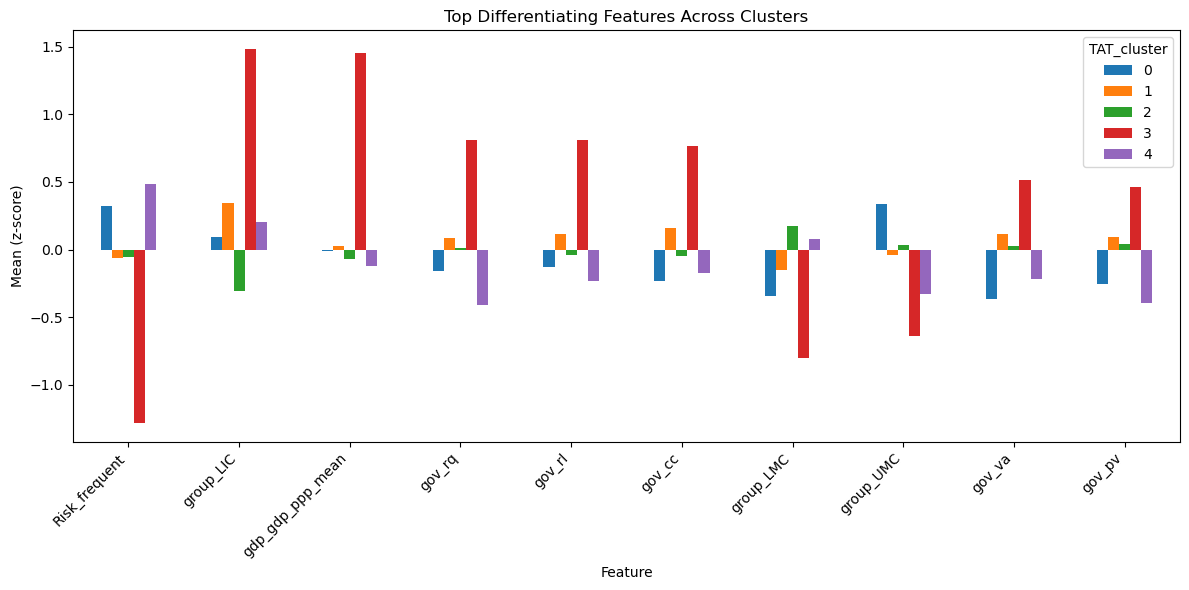

In [136]:
y_pred_full     = model.predict(X)
residuals_full  = (y - y_pred_full).values.reshape(-1, 1)

# Standardise the residuals
scaler_res = StandardScaler()
resid_std = scaler_res.fit_transform(residuals_full).flatten()
df_encoded['TAT_resid_std'] = resid_std

# Plot standardised residuals by cluster
plt.figure(figsize=(8, 5))
for cluster in sorted(df_encoded['TAT_cluster'].unique()):
    sub = df_encoded[df_encoded['TAT_cluster'] == cluster]
    plt.scatter(
        sub.index, sub['TAT_resid_std'],
        label=f"Cluster {cluster}", alpha=0.7
    )
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Standardised TAT Residuals by Cluster")
plt.xlabel("Country Index")
plt.ylabel("TAT Residual (z-score)")
plt.legend()
plt.tight_layout()
plt.show()

# Standardise all numeric features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(df_encoded[feature_cols])
df_scaled = pd.DataFrame(
    X_scaled, 
    columns=feature_cols, 
    index=df_encoded.index
)

# Recompute cluster‐means on the standardised features
cluster_means_std = (
    df_scaled
    .groupby(df_encoded["TAT_cluster"])
    .mean()
    .T
)

# Pick top‐10 differentiators and plot
top10 = (
    cluster_means_std
    .std(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

cluster_means_std.loc[top10] \
    .plot(kind='bar', figsize=(12, 6))
plt.title("Top Differentiating Features Across Clusters")
plt.ylabel("Mean (z-score)")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

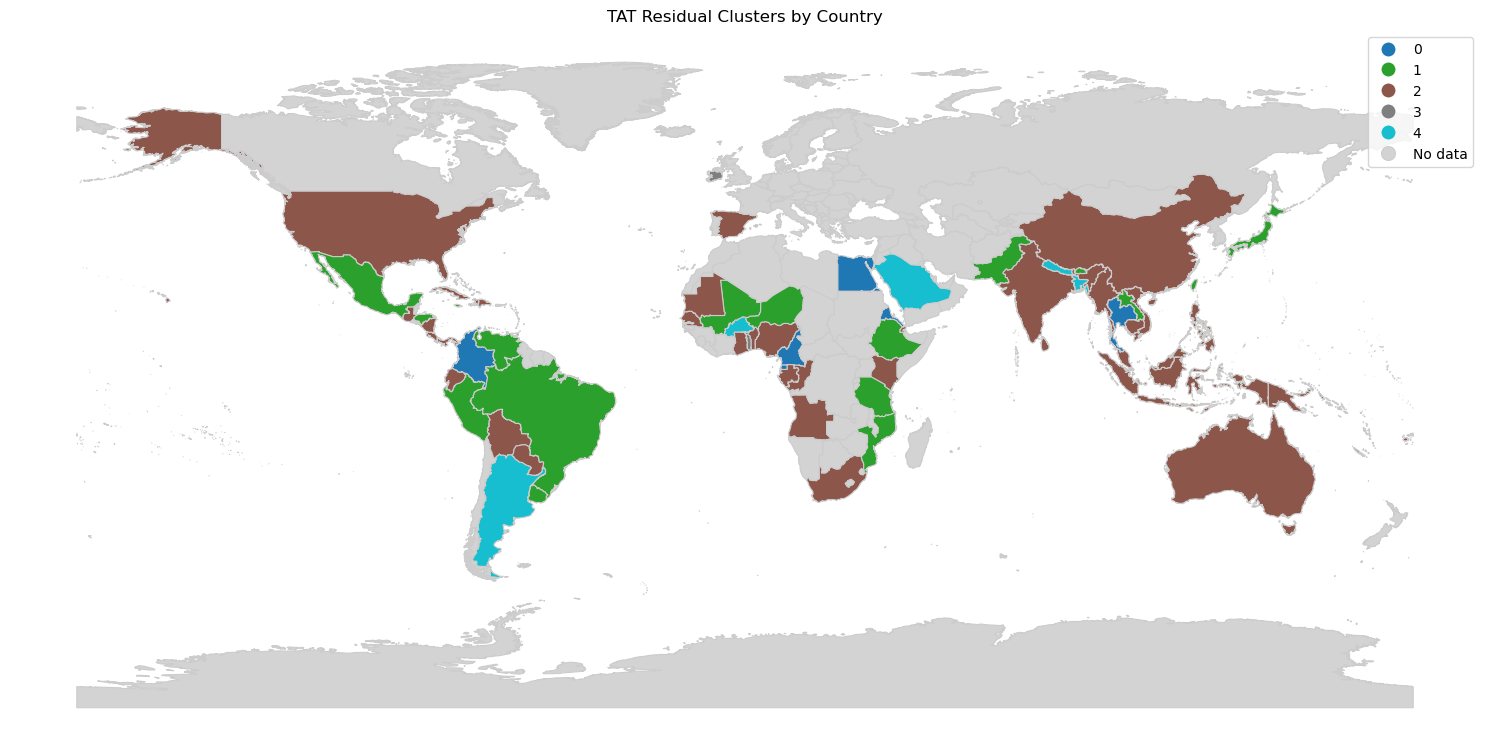

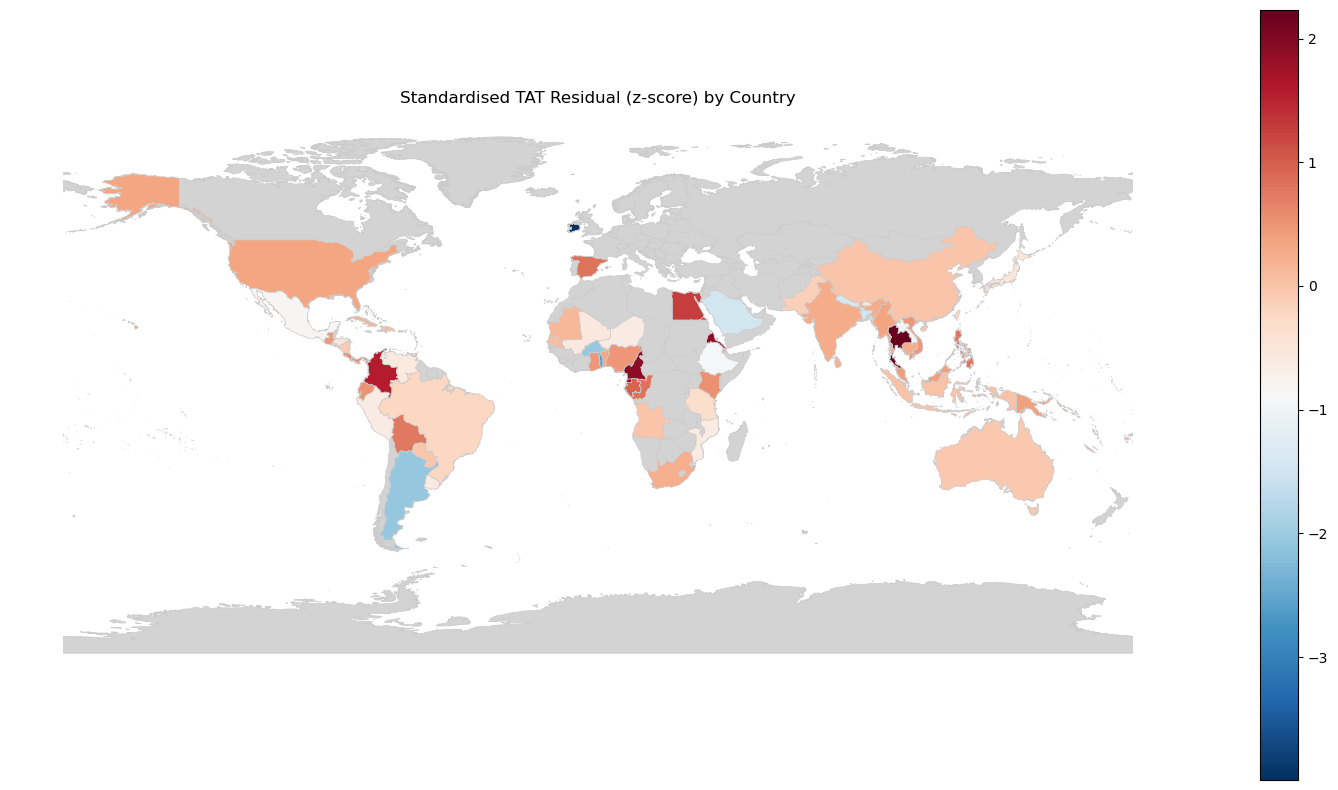

In [140]:
# Define feature matrix
X_all = df_encoded[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Recompute residuals using only those columns
y_pred_full    = model.predict(X_all)          
residuals_full = (y - y_pred_full).values.reshape(-1, 1)

# Standardise residuals
scaler_res    = StandardScaler()
resid_std     = scaler_res.fit_transform(residuals_full).flatten()
df_encoded['TAT_resid_std'] = resid_std         

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_all)        
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df_encoded.index)

# Clustering
cluster_model = KMeans(n_clusters=5, random_state=42)
df_encoded['TAT_cluster'] = cluster_model.fit_predict(resid_std.reshape(-1, 1))

# Build map DataFrame using the recomputed residuals & clusters
country_clusters = df_encoded[['country_code',
                               'pre_median_turnaround_days']].copy()
country_clusters['TAT_residual']  = residuals_full.flatten()
country_clusters['TAT_resid_std'] = resid_std
country_clusters['TAT_cluster']   = df_encoded['TAT_cluster'].astype('category')

# Load world geometries
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)
world = world.rename(columns={"ISO3166-1-Alpha-3": "country_code"})

# Merge on ISO3
map_df = world.merge(
    country_clusters,
    on="country_code",
    how="left"
)

# Plot 1: Cluster labels
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
map_df.plot(
    column='TAT_cluster',
    cmap='tab10',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    categorical=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("TAT Residual Clusters by Country")
ax.axis('off')
plt.tight_layout()
plt.show()

# Plot 2: Standardised residuals (z-scores)
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
map_df.plot(
    column='TAT_resid_std',
    cmap='RdBu_r',
    linewidth=0.5,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Standardised TAT Residual (z-score) by Country")
ax.axis('off')
plt.tight_layout()
plt.show()

/Users/oliviawilko/anaconda3/envs/dengue_subsampler/lib/python3.11/site-packages/geopandas/plotting.py:945: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 3
  ax.legend(**legend_kwds)


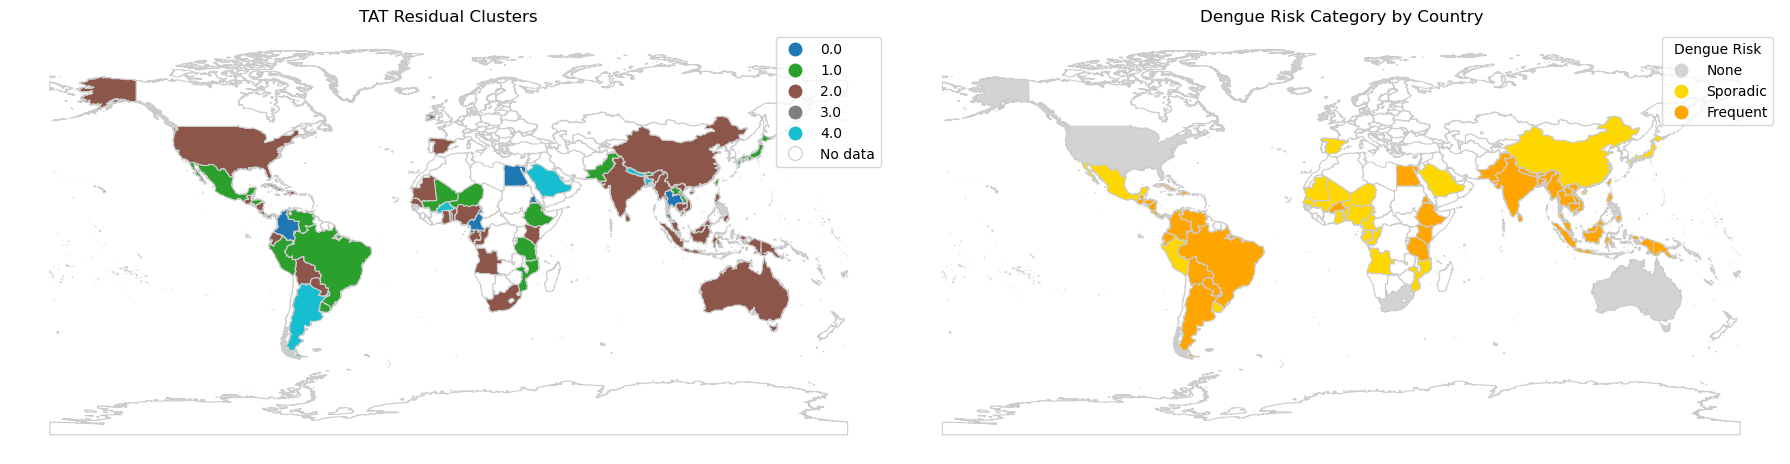

In [141]:
# Reconstruct Risk as a single categorical column
conditions = [
    df_encoded['Risk_frequent'] == 1,
    df_encoded['Risk_sporadic']  == 1
]
choices = ['frequent', 'sporadic']
df_encoded['Risk'] = np.select(conditions, choices, default='none')
df_encoded['Risk'] = pd.Categorical(
    df_encoded['Risk'],
    categories=['none','sporadic','frequent']
)

# Load & prepare world geometries
world = (
    gpd.read_file(
        "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    )
    .rename(columns={"ISO3166-1-Alpha-3": "country_code"})
    .set_index('country_code')
)

# Merge only the columns needed
map_df = world.join(
    df_encoded.set_index('country_code')[['TAT_cluster','Risk']],
    how='left'
)

# Define colormaps
risk_cmap    = ListedColormap(['lightgrey','#FFD700','#FFA500'])
cluster_cmap = 'tab10' 

# Plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18,8))

# a) TAT clusters
map_df.plot(
    column='TAT_cluster',
    categorical=True,
    cmap=cluster_cmap,
    legend=True,
    linewidth=0.8,
    edgecolor='0.8',
    missing_kwds={'color':'white','label':'No data'},
    ax=ax1
)
ax1.set_title("TAT Residual Clusters")
ax1.axis('off')

# b) Dengue Risk
map_df.plot(
    column='Risk',
    categorical=True,
    cmap=risk_cmap,
    legend=True,
    legend_kwds={'title':'Dengue Risk','labels':['None','Sporadic','Frequent']},
    linewidth=0.8,
    edgecolor='0.8',
    missing_kwds={'color':'white','label':'No data'},
    ax=ax2
)
ax2.set_title("Dengue Risk Category by Country")
ax2.axis('off')

plt.tight_layout()
plt.show()

In [142]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X = df_encoded[['TAT_resid_std']]

sil = silhouette_score(X, df_encoded['TAT_cluster'])
ch  = calinski_harabasz_score(X, df_encoded['TAT_cluster'])
db  = davies_bouldin_score(X, df_encoded['TAT_cluster'])

print(f"Silhouette score:          {sil:.3f}")
print(f"Calinski–Harabasz index:   {ch:.1f}")
print(f"Davies–Bouldin index:      {db:.3f}")

Silhouette score:          0.579
Calinski–Harabasz index:   207.3
Davies–Bouldin index:      0.505


In [150]:
import bambi as bmb
import arviz as az

df_encoded['log_TAT'] = np.log(df_encoded['pre_median_turnaround_days'])

# Prepare data
data = df_encoded.copy()
data['TAT_cluster'] = data['TAT_cluster'].astype('category')

# Specify & fit model on log_TAT with Gaussian family
model_ln = bmb.Model(
    "log_TAT ~ 1 + TAT_cluster",
    data
)
idata_ln = model_ln.fit(
    draws=2000,
    tune=1000,
    cores=2,
    return_inference_data=True
)

# Inspect posterior variable names 
all_vars = list(idata_ln.posterior.data_vars)
print("Posterior variables:\n", "\n".join(all_vars))

# 4utomatically pick out the cluster‐level names
cluster_vars = [v for v in all_vars if v.startswith("TAT_cluster")]
print("\nDetected cluster variables:\n", cluster_vars)

# Build var_names list for summary
summary_vars = ["Intercept"] + cluster_vars + ["sigma"]

# Summarise!
summary_ln = az.summary(
    idata_ln,
    var_names=summary_vars,
    hdi_prob=0.95
)
print(summary_ln)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, Intercept, TAT_cluster]


/Users/oliviawilko/anaconda3/envs/dengue_subsampler/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 30 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Posterior variables:
 sigma
Intercept
TAT_cluster

Detected cluster variables:
 ['TAT_cluster']
                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
Intercept       7.998  0.116     7.765      8.216      0.002    0.002   
TAT_cluster[1] -0.977  0.139    -1.251     -0.708      0.003    0.002   
TAT_cluster[2] -0.594  0.130    -0.852     -0.350      0.003    0.002   
TAT_cluster[3] -2.101  0.274    -2.666     -1.588      0.005    0.004   
TAT_cluster[4] -1.560  0.175    -1.907     -1.218      0.003    0.003   
sigma           0.350  0.029     0.294      0.404      0.000    0.000   

                ess_bulk  ess_tail  r_hat  
Intercept         2436.0    2343.0    1.0  
TAT_cluster[1]    2405.0    2577.0    1.0  
TAT_cluster[2]    2594.0    2577.0    1.0  
TAT_cluster[3]    3398.0    2831.0    1.0  
TAT_cluster[4]    3355.0    2920.0    1.0  
sigma             3963.0    2864.0    1.0  
